In [1]:
import matplotlib.pyplot as plt
import sklearn.decomposition as sd # importing the functions of dimension reduction ( sub_library)
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv('/content/drive/MyDrive/AI Datasets/test_rows.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   RPA2_3     104 non-null    float64
 1   ZYG11A_4   104 non-null    float64
 2   F5_2       104 non-null    float64
 3   HOXC4_1    104 non-null    float64
 4   NKIRAS2_2  104 non-null    float64
 5   MEIS1_1    104 non-null    float64
 6   SAMD10_2   104 non-null    float64
 7   GRM2_9     104 non-null    float64
 8   TRIM59_5   104 non-null    float64
 9   LDB2_3     104 non-null    float64
 10  ELOVL2_6   104 non-null    float64
 11  DDO_1      104 non-null    float64
 12  KLF14_2    104 non-null    float64
dtypes: float64(13)
memory usage: 10.7 KB


In [5]:
df

,RPA2_3,ZYG11A_4,F5_2,HOXC4_1,NKIRAS2_2,MEIS1_1,SAMD10_2,GRM2_9,TRIM59_5,LDB2_3,ELOVL2_6,DDO_1,KLF14_2
0,65.96,18.08,41.57,55.46,30.69,63.42,40.86,68.88,44.32,56.17,62.29,40.99,2.30
1,66.83,20.27,40.55,49.67,29.53,30.47,37.73,53.30,50.09,58.40,61.10,49.73,1.07
2,50.30,11.74,40.17,33.85,23.39,58.83,38.84,35.08,35.90,58.81,50.38,63.03,0.95
3,65.54,15.56,33.56,36.79,20.23,56.39,41.75,50.37,41.46,58.05,50.58,62.13,1.99
4,59.01,14.38,41.95,30.30,24.99,54.40,37.38,30.35,31.28,65.80,48.74,41.88,0.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,58.69,18.35,44.93,47.38,28.52,27.93,36.91,38.85,43.60,66.52,50.38,61.35,2.36
100,63.83,12.09,41.90,44.60,24.75,39.18,36.72,59.16,47.58,61.89,56.56,46.96,2.32
101,74.61,24.72,31.47,56.47,27.28,20.12,29.83,65.22,54.89,43.36,68.69,16.45,6.54
102,66.44,20.96,34.99,55.25,23.77,49.99,36.05,73.52,51.74,49.90,67.48,36.06,4.22


In [6]:
# Selecting the 13 features from your dataset
X = df[['RPA2_3', 'ZYG11A_4', 'F5_2', 'HOXC4_1', 'NKIRAS2_2', 'MEIS1_1', 'SAMD10_2', 'GRM2_9', 'TRIM59_5', 'LDB2_3', 'ELOVL2_6', 'DDO_1', 'KLF14_2']]
X

,RPA2_3,ZYG11A_4,F5_2,HOXC4_1,NKIRAS2_2,MEIS1_1,SAMD10_2,GRM2_9,TRIM59_5,LDB2_3,ELOVL2_6,DDO_1,KLF14_2
0,65.96,18.08,41.57,55.46,30.69,63.42,40.86,68.88,44.32,56.17,62.29,40.99,2.30
1,66.83,20.27,40.55,49.67,29.53,30.47,37.73,53.30,50.09,58.40,61.10,49.73,1.07
2,50.30,11.74,40.17,33.85,23.39,58.83,38.84,35.08,35.90,58.81,50.38,63.03,0.95
3,65.54,15.56,33.56,36.79,20.23,56.39,41.75,50.37,41.46,58.05,50.58,62.13,1.99
4,59.01,14.38,41.95,30.30,24.99,54.40,37.38,30.35,31.28,65.80,48.74,41.88,0.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,58.69,18.35,44.93,47.38,28.52,27.93,36.91,38.85,43.60,66.52,50.38,61.35,2.36
100,63.83,12.09,41.90,44.60,24.75,39.18,36.72,59.16,47.58,61.89,56.56,46.96,2.32
101,74.61,24.72,31.47,56.47,27.28,20.12,29.83,65.22,54.89,43.36,68.69,16.45,6.54
102,66.44,20.96,34.99,55.25,23.77,49.99,36.05,73.52,51.74,49.90,67.48,36.06,4.22


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Standardize the data (Mean=0, Variance=1)
# This is a critical step for PCA when features have different scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA to reduce the dataset to 3 dimensions
pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_scaled)

# 3. Convert the reduced data into a readable DataFrame
X_reduced_df = pd.DataFrame(
    data=X_reduced,
    columns=['PC1', 'PC2', 'PC3']
)

# Display the first few rows of the 3D data
print(X_reduced_df.head())

# Check how much information (variance) was captured
print(f"\nTotal Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

        PC1       PC2       PC3
0  0.077154  1.828090 -0.093171
1  0.471365  1.189446  0.354301
2 -2.809852 -0.816410  0.156898
3 -0.916951 -0.021200  0.472466
4 -2.676589 -0.950793  0.934128

Total Explained Variance: 69.83%


In [15]:
X_reduced

array([[ 7.71536609e-02,  1.82808997e+00, -9.31706268e-02],
       [ 4.71364525e-01,  1.18944597e+00,  3.54301356e-01],
       [-2.80985249e+00, -8.16409548e-01,  1.56897761e-01],
       [-9.16951416e-01, -2.12000120e-02,  4.72466139e-01],
       [-2.67658887e+00, -9.50792734e-01,  9.34128376e-01],
       [ 9.99331809e-01,  1.73632977e-01,  4.89013131e-02],
       [-1.74023950e+00, -1.07255896e-01,  1.42057261e+00],
       [ 2.44125211e+00, -2.40775586e-01, -3.10762570e-01],
       [ 3.64397471e+00, -2.96166725e-02, -6.67206352e-01],
       [-2.09656633e+00,  1.20689225e+00, -7.83393127e-01],
       [-2.33836041e-01, -1.21341279e+00,  3.53630817e-01],
       [ 3.13906744e+00, -2.54627564e-01, -2.92162717e-01],
       [ 1.37101815e+00,  7.97913629e-01, -1.36035029e+00],
       [ 2.51740805e+00, -2.19316987e-01, -7.12555372e-02],
       [-4.25215717e+00, -5.23106099e-01, -5.45163883e-01],
       [-1.33532198e+00, -1.28845062e+00,  2.96352845e-01],
       [-3.28720416e+00,  1.04778290e+00

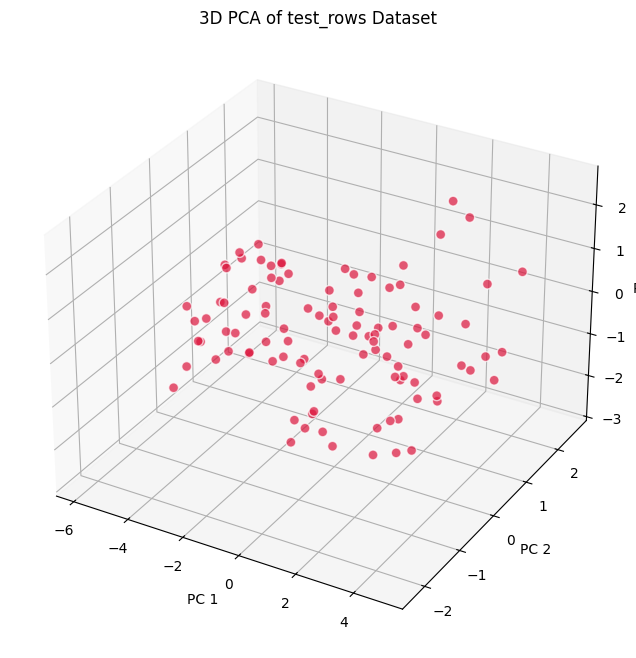

In [16]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting PC1, PC2, and PC3
ax.scatter(X_reduced[:, 0], X_reduced[:, 1], X_reduced[:, 2],
           c='crimson', marker='o', s=50, alpha=0.7, edgecolors='w')

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('3D PCA of test_rows Dataset')

plt.show()

In [17]:
import pandas as pd

# 1. Create a copy of your original 13 features
# This ensures we don't modify the original 'X' variable
df_pca_3d = X.copy()

# 2. Add the 3 Principal Components as new columns
# X_reduced is the array created in your previous PCA step
df_pca_3d['PC1'] = X_reduced[:, 0]
df_pca_3d['PC2'] = X_reduced[:, 1]
df_pca_3d['PC3'] = X_reduced[:, 2]

# 3. Display the combined DataFrame
# You will now see your original data (RPA2_3, etc.) followed by PC1, PC2, and PC3
df_pca_3d

,RPA2_3,ZYG11A_4,F5_2,HOXC4_1,NKIRAS2_2,MEIS1_1,SAMD10_2,GRM2_9,TRIM59_5,LDB2_3,ELOVL2_6,DDO_1,KLF14_2,PC1,PC2,PC3
0,65.96,18.08,41.57,55.46,30.69,63.42,40.86,68.88,44.32,56.17,62.29,40.99,2.30,0.077154,1.828090,-0.093171
1,66.83,20.27,40.55,49.67,29.53,30.47,37.73,53.30,50.09,58.40,61.10,49.73,1.07,0.471365,1.189446,0.354301
2,50.30,11.74,40.17,33.85,23.39,58.83,38.84,35.08,35.90,58.81,50.38,63.03,0.95,-2.809852,-0.816410,0.156898
3,65.54,15.56,33.56,36.79,20.23,56.39,41.75,50.37,41.46,58.05,50.58,62.13,1.99,-0.916951,-0.021200,0.472466
4,59.01,14.38,41.95,30.30,24.99,54.40,37.38,30.35,31.28,65.80,48.74,41.88,0.90,-2.676589,-0.950793,0.934128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,58.69,18.35,44.93,47.38,28.52,27.93,36.91,38.85,43.60,66.52,50.38,61.35,2.36,-1.156252,0.735035,-0.405782
100,63.83,12.09,41.90,44.60,24.75,39.18,36.72,59.16,47.58,61.89,56.56,46.96,2.32,-0.252929,0.238173,-0.100047
101,74.61,24.72,31.47,56.47,27.28,20.12,29.83,65.22,54.89,43.36,68.69,16.45,6.54,4.520440,-0.075369,0.224459
102,66.44,20.96,34.99,55.25,23.77,49.99,36.05,73.52,51.74,49.90,67.48,36.06,4.22,2.349135,0.707580,-0.049750


In [12]:
# how to visualize 3d dataframe

import plotly.express as px

fig = px.scatter_3d(df_pca_3d, x="PC1", y="PC2", z="PC3")
fig.show()

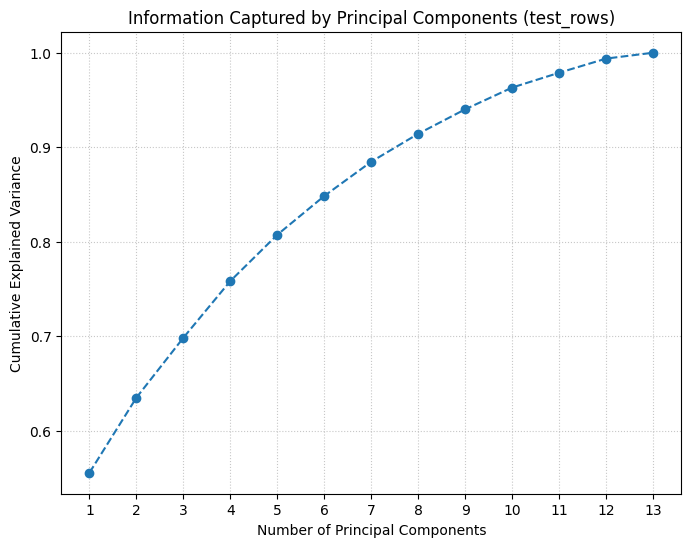

Component 1 captures: 55.53% of the data info
Component 2 captures: 7.95% of the data info
Component 3 captures: 6.34% of the data info
Component 4 captures: 6.01% of the data info
Component 5 captures: 4.90% of the data info
Component 6 captures: 4.11% of the data info
Component 7 captures: 3.63% of the data info
Component 8 captures: 2.96% of the data info
Component 9 captures: 2.59% of the data info
Component 10 captures: 2.30% of the data info
Component 11 captures: 1.57% of the data info
Component 12 captures: 1.50% of the data info
Component 13 captures: 0.62% of the data info


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Standardize the features
# PCA is distance-based, so all 13 features must be on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit PCA to all 13 components
# This calculates how much "information power" each column provides
pca_full = PCA().fit(X_scaled)

# 3. Plot the Cumulative Explained Variance
plt.figure(figsize=(8, 6))

# We plot the cumulative sum of the variance ratios
# range(1, 14) ensures the x-axis labels match your 13 components
plt.plot(range(1, 14), np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Information Captured by Principal Components (test_rows)')
plt.xticks(range(1, 14)) # Force x-axis to show every component number
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Print the "Power" of each individual component
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"Component {i+1} captures: {var:.2%} of the data info")

In [19]:
X_scaled

array([[ 0.24255746,  0.10262281,  0.45259086, ...,  0.50482418,
        -0.47949649, -0.37792975],
       [ 0.35509836,  0.4938744 ,  0.29059458, ...,  0.39104338,
         0.20495203, -0.98950184],
       [-1.78317859, -1.03004163,  0.23024302, ..., -0.63394002,
         1.24650414, -1.04916741],
       ...,
       [ 1.36149852,  1.28888335, -1.15148998, ...,  1.11675457,
        -2.4012776 ,  1.73025371],
       [ 0.30464899,  0.61714545, -0.59244399, ...,  1.00106148,
        -0.86557558,  0.57671936],
       [-1.93452669, -0.87997253,  1.29115985, ..., -0.55744872,
        -1.03159742, -0.37792975]])

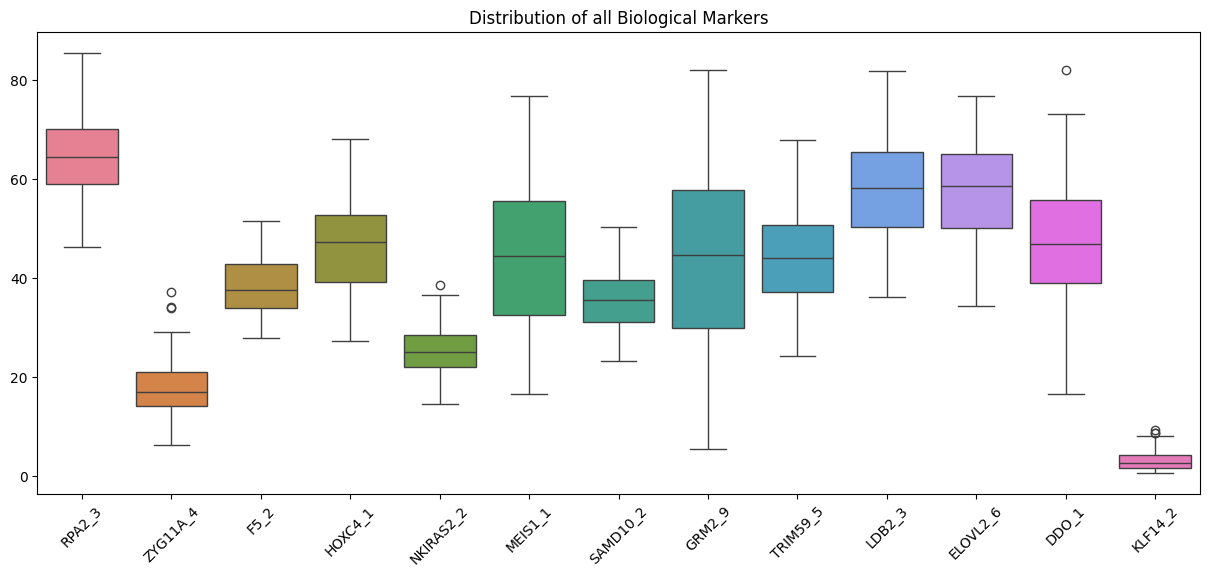

In [20]:
import seaborn as sb
import matplotlib.pyplot as plt

# Increase figure size so labels don't overlap
plt.figure(figsize=(15, 6))

# Passing the entire dataframe (df) will create a box for every column
sb.boxplot(data=df)

plt.title('Distribution of all Biological Markers')
plt.xticks(rotation=45) # Rotate names so they are readable
plt.show()

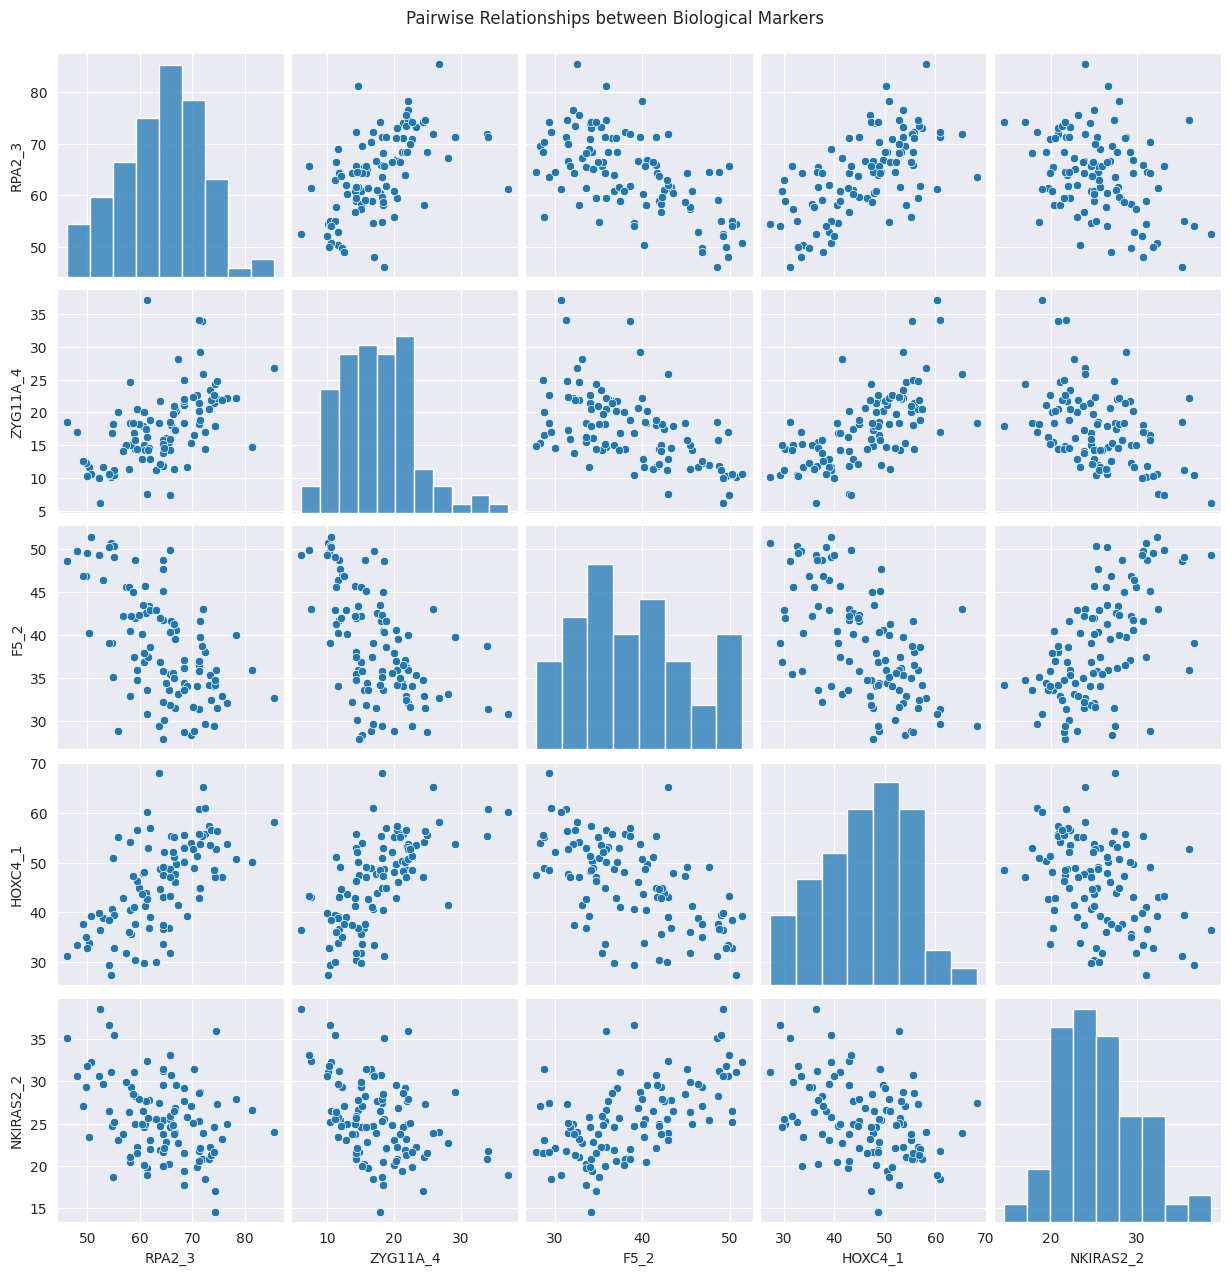

In [21]:
import seaborn as sb
import matplotlib.pyplot as plt

# 1. Set the background style
sb.set_style('darkgrid')

# 2. Select a subset of features for a cleaner view (e.g., the first 5)
# You can change these names to any of your 13 markers
subset_features = ['RPA2_3', 'ZYG11A_4', 'F5_2', 'HOXC4_1', 'NKIRAS2_2']

# 3. Create the pairplot
# Note: We removed the 'hue' argument since there are no category labels
sb.pairplot(df[subset_features])

# Add a title
plt.suptitle('Pairwise Relationships between Biological Markers', y=1.02)
plt.show()